In [11]:
import numpy as np
from typing import Union
from pathlib import Path

from model_ranking.GBC import bhattacharyya_coefficient
from model_ranking.yaml_generators import (
    MODEL_ABBREVIATIONS_TO_DATASET,
)
from model_ranking.utils import load_h5

In [3]:
Unet_models = ["E_model5", "Hm_model4", "Rm_model4", "V_model2"]
Unet_models_NA = ["E_model_NA2", "Hm_model_NA2", "Rm_model_NA2", "V_model_NA2"]
Unetr_models = ["E_model_Unetr2", "Hm_model_Unetr2", "Rm_model_Unetr2"]
ResUnet_models = ["E_model_Res1", "Hm_model_Res1", "Rm_model_Res1", "V_model_Res1"]

In [4]:
feature_base_path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria"

In [5]:
def get_precomputed_feature_path(
    model_name: str, 
    target: str, 
    base_path: Union[str, Path]):
    if isinstance(base_path, str):
        base_path = Path(base_path)
    source = MODEL_ABBREVIATIONS_TO_DATASET[model_name.split('_')[0]]
    paths = list(base_path.rglob(f"{source}_to_{target}/**/{model_name}_to_{target}_features.npz"))
    assert len(paths) == 1, f"Expected exactly one path for {model_name} to {target}, found {len(paths)}"
    return paths[0]

In [13]:
def get_NA_performance_score(
        model_name: str,
        target: str,
        base_path: Union[str, Path],
        performance_key: str = "hard_f1",
        approach: str = "feature_perturbation_consistency",
        run_id: str = "FP_full"
):
    if isinstance(base_path, str):
        base_path = Path(base_path)
    source = MODEL_ABBREVIATIONS_TO_DATASET[model_name.split('_')[0]]
    paths = list(base_path.rglob(f"{source}_to_{target}_gap/{approach}/{run_id}/{model_name}/**/none/**/*predictions.h5"))
    assert len(paths) == 1, f"Expected exactly one path for {model_name} to {target}, found {len(paths)}"
    performance_score = load_h5(paths[0], performance_key)
    return performance_score

In [14]:
f1_score = get_NA_performance_score(
    model_name="E_model_NA2",
    target="Hmito",
    base_path="/scratch/talks/consistency_results/patch_segmentation/mitochondria",
)

In [15]:
print(f1_score.shape)

(3750, 2)


In [69]:
def load_npz(path: Union[str, Path], key: str):
    data = np.load(path)
    if key not in data:
        raise KeyError(f"Key '{key}' not found in {path}")
    return data[key]

In [70]:
all_models = Unet_models + Unet_models_NA + Unetr_models + ResUnet_models
print(all_models)

['E_model5', 'Hm_model4', 'Rm_model4', 'V_model2', 'E_model_NA2', 'Hm_model_NA2', 'Rm_model_NA2', 'V_model_NA2', 'E_model_Unetr2', 'Hm_model_Unetr2', 'Rm_model_Unetr2', 'E_model_Res1', 'Hm_model_Res1', 'Rm_model_Res1', 'V_model_Res1']


In [88]:
targets = ["EPFL"]
source_models = Unet_models + Unet_models_NA + Unetr_models + ResUnet_models
feature_base_path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria"
save_keys = {
    "NA": "decoders.2",
    "Unetr": "decoder2",
    "Res": "decoders.3",
}
gbc_per_target = {}
feature_ids = list(save_keys.keys())
for target in targets:
    gbc_per_model = {}
    for model in source_models:
        if ("V" in model) and (target == "VNC"):
            continue
        else:
            model_identifier = model.split('_')[-1][:-1]
            if model_identifier in feature_ids:
                key = save_keys[model_identifier]
            else:
                key = "decoders.2"

            feature_path = get_precomputed_feature_path(model, target, feature_base_path)
            features = load_npz(feature_path, f"{key}_features")
            labels = load_npz(feature_path, f"{key}_labels")

            non_zero_patch_ids = np.where(~np.all(labels == 0, axis=1))[0]
            features = features[non_zero_patch_ids]
            labels = labels[non_zero_patch_ids]

            features_flat = features.reshape(-1, features.shape[-1])
            labels_flat = labels.reshape(-1)

            gbc = bhattacharyya_coefficient(features_flat, labels_flat)
            gbc_per_model[model] = gbc

            # gbc_total = 0
            # for i in range(len(features)):
            #     gbc_total += bhattacharyya_coefficient(features[i], labels[i])
            # gbc_per_model[model] = gbc_total
    gbc_per_target[target] = gbc_per_model


In [89]:
gbc_per_target

{'EPFL': {'E_model5': -1.6772560125898026,
  'Hm_model4': -1.9804640960648456,
  'Rm_model4': -1.920968383637294,
  'V_model2': -1.9361057997798956,
  'E_model_NA2': -1.8514835757271122,
  'Hm_model_NA2': -1.971344268330668,
  'Rm_model_NA2': -1.9561789536769598,
  'V_model_NA2': -1.9935038894582906,
  'E_model_Unetr2': -1.990557168572766,
  'Hm_model_Unetr2': -1.9289331747002554,
  'Rm_model_Unetr2': -1.8984704323451094,
  'E_model_Res1': -1.9715345460422358,
  'Hm_model_Res1': -1.893928375002596,
  'Rm_model_Res1': -1.97907806172131,
  'V_model_Res1': -1.8214991406412198}}

In [73]:
from typing import Dict, List, Any
import numpy as np
from numpy.typing import NDArray
import pandas as pd

from model_ranking.results import (
    get_summary_results, 
    per_source_model_results,
    cmb_consistency_score_weighted_average,
    per_target_consis_result_type,
    per_target_performance_result_type,
)
from model_ranking.plots import plot_alpha_sweep_specific_norm
from model_ranking.correlation import (
    calculate_correlation_statistics
)

INFO: P [MainThread] 2025-08-07 16:29:10,345 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [74]:
NA_UNet_source_models = {
    "EPFL": "E_model_NA2",
    "Hmito": "Hm_model_NA2",
    "Rmito": "Rm_model_NA2",
    "VNC": "V_model_NA2",
}
Res_source_models = {
    "EPFL": "E_model_Res1",
    "Hmito": "Hm_model_Res1",
    "Rmito": "Rm_model_Res1",
    "VNC": "V_model_Res1",
}

Unetr_source_models = {
    "EPFL": "E_model_Unetr2",
    "Hmito": "Hm_model_Unetr2",
    "Rmito": "Rm_model_Unetr2",
}
Unet_source_models={
    "EPFL": "E_model5",
    "Hmito": "Hm_model4",
    "Rmito": "Rm_model4",
    "VNC": "V_model2",
}
consis_keys={
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
consis_keys_bckg = {
    "EPFL": "EI_consis_bckg",
    "Hmito": "EI_consis_bckg",
    "Rmito": "EI_consis_bckg",
    "VNC": "EI_consis_bckg",
}
result_folders={
    "EPFL": "P_full",
    "Hmito": "P_full",
    "Rmito": "P_full",
    "VNC": "P_full",
}

per_target_norms: Dict[str, List[None]] = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}

perf_key = "hard_f1"
approach="consistency"
base_result_path = "/scratch/talks/consistency_results/patch_segmentation/mitochondria"

In [75]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
}
targets = ["EPFL"]
source_model_types = [NA_UNet_source_models, Res_source_models, Unet_source_models, Unetr_source_models]

In [76]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        if "Unetr" in model_type["EPFL"]:
            sources = ["EPFL", "Hmito", "Rmito"] 
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 115.48it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 121.96it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 181.45it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 169.51it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 196.60it/s]


In [83]:
per_target_forg_performance["EPFL"]

{'E_model_NA2': {'norm_Normalize': 0.8867508172988892},
 'Hm_model_NA2': {'norm_Normalize': 0.6937870979309082},
 'Rm_model_NA2': {'norm_Normalize': 0.10001395642757416},
 'V_model_NA2': {'norm_Normalize': 0.6054315567016602},
 'E_model_Res1': {'norm_Normalize': 0.9407505989074707},
 'Hm_model_Res1': {'norm_Normalize': 0.8338801860809326},
 'Rm_model_Res1': {'norm_Normalize': 0.032384369522333145},
 'V_model_Res1': {'norm_Normalize': 0.4776468276977539},
 'E_model5': {'norm_Normalize': 0.9456775188446045},
 'Hm_model4': {'norm_Normalize': 0.7714987993240356},
 'Rm_model4': {'norm_Normalize': 0.3006330728530884},
 'V_model2': {'norm_Normalize': 0.14098334312438965},
 'E_model_Unetr2': {'norm_Normalize': 0.9188569784164429},
 'Hm_model_Unetr2': {'norm_Normalize': 0.8077123761177063},
 'Rm_model_Unetr2': {'norm_Normalize': 0.5673959255218506}}

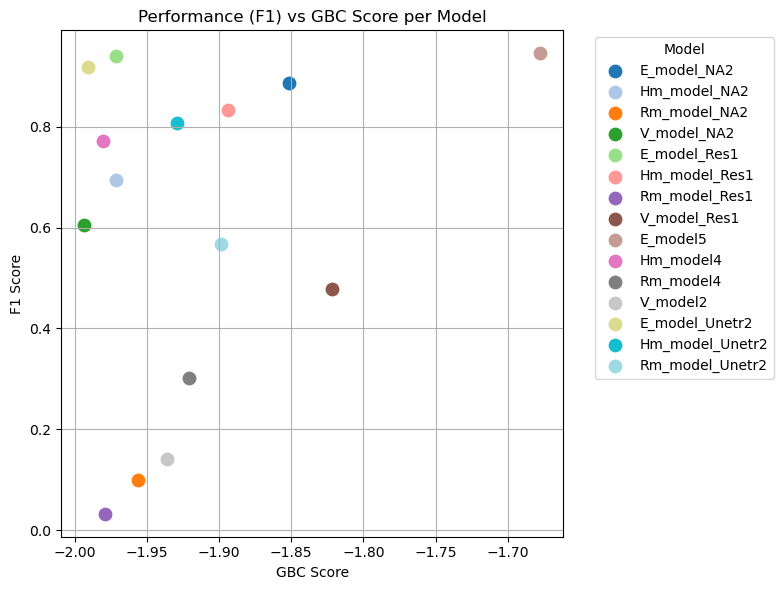

In [90]:
import matplotlib.pyplot as plt

def plot_performance_vs_gbc(performance_dict, gbc_dict):
    """
    Plots a scatter plot of performance (F1 score) vs GBC score for each model.
    
    Parameters:
    - performance_dict: dict, mapping model_name to {'norm_Normalize': F1_score}
    - gbc_dict: dict, mapping model_name to gbc_score
    """
    model_names = list(performance_dict.keys())
    colors = plt.get_cmap('tab20', len(model_names))
    
    x = []
    y = []
    labels = []
    for idx, model in enumerate(model_names):
        if model in gbc_dict and 'norm_Normalize' in performance_dict[model]:
            x.append(gbc_dict[model])
            y.append(performance_dict[model]['norm_Normalize'])
            labels.append(model)
    
    _ = plt.figure(figsize=(8, 6))
    for i, model in enumerate(labels):
        _ = plt.scatter(x[i], y[i], color=colors(i), label=model, s=80)
    
    _ = plt.xlabel('GBC Score')
    _ = plt.ylabel('F1 Score')
    _ = plt.title('Performance (F1) vs GBC Score per Model')
    _ = plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid()
    plt.show()

# Example usage:
plot_performance_vs_gbc(per_target_forg_performance["EPFL"], gbc_per_target["EPFL"])

In [16]:
EtoE_feature_path = get_precomputed_feature_path("E_model5", "EPFL", Path(feature_base_path))
EtoE_features = load_npz(EtoE_feature_path, "decoders.2_features")
EtoE_labels = load_npz(EtoE_feature_path, "decoders.2_labels")
print(EtoE_features.shape)
print(EtoE_labels.shape)

(750, 1000, 32)
(750, 1000)


In [64]:
targets = ["EPFL", "Hmito", "Rmito", "VNC"]

for target in targets:
    feature_path = get_precomputed_feature_path("E_model5", target, Path(feature_base_path))
    features = load_npz(feature_path, "decoders.2_features")
    labels = load_npz(feature_path, "decoders.2_labels")
    print(features.shape)
    print(labels.shape)

    non_zero_patch_ids = np.where(~np.all(labels == 0, axis=1))[0]
    print(f"Number of non-zero labels in {target}: {len(non_zero_patch_ids)}")

(750, 1000, 32)
(750, 1000)
Number of non-zero labels in EPFL: 712
(3750, 1000, 32)
(3750, 1000)
Number of non-zero labels in Hmito: 3556
(3750, 1000, 32)
(3750, 1000)
Number of non-zero labels in Rmito: 3537
(180, 1000, 32)
(180, 1000)
Number of non-zero labels in VNC: 180


In [18]:
labels, counts = np.unique(EtoE_labels[0], return_counts=True)
print(dict(zip(labels, counts)))

{0.0: 351, 1.0: 649}


In [21]:
zero_rows = np.where(np.all(EtoE_labels == 0, axis=1))[0]
print(zero_rows)

[198 204 210 216 222 228 234 240 246 252 258 264 270 276 282 288 294 300
 306 312 318 324 330 336 342 348 354 360 693 699 705 711 717 723 729 735
 741 747]


In [22]:
np.unique(EtoE_labels[198])

array([0.], dtype=float32)

In [19]:
EtoE_features[0][:10].shape

(10, 32)

In [27]:
EtoE_features_flat = EtoE_features.reshape(-1, EtoE_features.shape[-1])
EtoE_labels_flat = EtoE_labels.reshape(-1)
print(EtoE_features_flat.shape)
print(EtoE_labels_flat.shape)

(750000, 32)
(750000,)


In [28]:
gbc = bhattacharyya_coefficient(EtoE_features_flat, EtoE_labels_flat)
print(gbc)

-1.6663244018806511


In [ ]:
features_full = EtoE_features
labels_full = EtoE_labels

non_zero_patch_ids = np.where(~np.all(labels_full == 0, axis=1))[0]
print(len(non_zero_patch_ids))


712
[0. 1.]


In [ ]:
from numpy.typing import NDArray
from typing import Any, List
from sklearn.decomposition import PCA
from model_ranking.utils import is_ndarray

def test_gbc_num_sample_dependency(
    features: NDArray[Any],
    labels: NDArray[Any], 
    num_patches: List[int] = [10, 50, 100, 200, 300, 400, 500, 600]
):
    
    # find non empty patches
    non_zero_patch_ids = np.where(~np.all(labels == 0, axis=1))[0]
    print(f"Non-zero patches found: {len(non_zero_patch_ids)}")
    
    # Test sample size dependency with full real data
    print("\n--- Sample size dependency (full real data) ---")
    total_samples = len(non_zero_patch_ids)
    num_patches = num_patches + [total_samples]  # Ensure total_samples is included
    gbc_scores_full: List[float] = []
    
    np.random.seed(42)
    
    for n_samples in num_patches:
        if n_samples > total_samples:
            n_samples = total_samples
            
        # Randomly subsample
        indices = np.random.choice(non_zero_patch_ids, n_samples, replace=False)
        features_subset = features[indices]
        labels_subset = labels[indices]

        features_subset_flat = features_subset.reshape(-1, features_subset.shape[-1])
        labels_subset_flat = labels_subset.reshape(-1)

        gbc = bhattacharyya_coefficient(features_subset_flat, labels_subset_flat)
        gbc_scores_full.append(gbc)
        print(f"Sample size: {n_samples:6d}, GBC: {gbc:.6f}")
    return num_patches, gbc_scores_full
    
def test_gbc_feature_size_dependency(
    features: NDArray[Any], 
    labels: NDArray[Any], 
    feature_sizes: List[int] = [4, 8, 16, 32]
):
    # Test dimensionality dependency using PCA
    original_dim = features.shape[1]
    gbc_scores_dim_full: List[float] = []

    # find non empty patches
    non_zero_patch_ids = np.where(~np.all(labels == 0, axis=1))[0]
    print(f"Non-zero patches found: {len(non_zero_patch_ids)}")

    features_foreground = features[non_zero_patch_ids]
    labels_foreground = labels[non_zero_patch_ids]

    features_for_dim = features_foreground.reshape(-1, features_foreground.shape[-1])
    labels_for_dim = labels_foreground.reshape(-1)

    
    
    for dim in feature_sizes:
        if dim <= original_dim:
            if dim == original_dim:
                # Use original features without PCA
                features_reduced = features_for_dim
            else:
                # Apply PCA to reduce to dim dimensions
                pca = PCA(n_components=dim, random_state=42)
                features_reduced = pca.fit_transform(features_for_dim) #pyright: ignore[reportUnknownVariableType]
            
            assert is_ndarray(features_reduced), f"Expected features_reduced to be a numpy array"
            
            gbc = bhattacharyya_coefficient(features_reduced, labels_for_dim)
            gbc_scores_dim_full.append(gbc)
            
            if dim == original_dim:
                print(f"Feature dim: {dim:3d}, GBC: {gbc:.6f} (original)")
            else:
                explained_var = np.sum(pca.explained_variance_ratio_)
                print(f"Feature dim: {dim:3d}, GBC: {gbc:.6f}, Explained var: {explained_var:.3f}")
            
        else:
            print(f"Skipping feature dim {dim} as it exceeds original dimension {original_dim}")
    
    return gbc_scores_dim_full

import matplotlib.pyplot as plt

def plot_gbc_dependency_analysis(
    num_patches: List[int], feature_dims: List[int], gbc_score_dataset_size: List[float], gbc_score_nDfeatures: List[float]):
    """
    Plot GBC dependency analysis for dataset size and feature dimensionality.
    
    Parameters:
    num_patches: list of int - number of samples tested
    feature_dims: list of int - feature dimensions tested  
    gbc_score_dataset_size: list of float - GBC scores for different dataset sizes
    gbc_score_nDfeatures: list of float - GBC scores for different feature dimensions
    """
    # Create subplots for visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot GBC vs Dataset Size
    ax1.plot(num_patches, gbc_score_dataset_size, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Number of Samples')
    ax1.set_ylabel('GBC Score')
    ax1.set_title('GBC Score vs Dataset Size')
    ax1.grid(True, alpha=0.3)

    # Plot GBC vs Feature Dimensionality  
    ax2.plot(feature_dims, gbc_score_nDfeatures, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Feature Dimensionality')
    ax2.set_ylabel('GBC Score')
    ax2.set_title('GBC Score vs Feature Dimensionality')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print some statistics
    print(f"GBC range for dataset size: {max(gbc_score_dataset_size) - min(gbc_score_dataset_size):.6f}")
    print(f"GBC range for feature dimensionality: {max(gbc_score_nDfeatures) - min(gbc_score_nDfeatures):.6f}")


Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.698402
Sample size:     50, GBC: -1.749785
Sample size:    100, GBC: -1.710290
Sample size:    200, GBC: -1.676847
Sample size:    300, GBC: -1.660514
Sample size:    400, GBC: -1.708927
Sample size:    500, GBC: -1.643599
Sample size:    600, GBC: -1.690359
Sample size:    712, GBC: -1.677285
Non-zero patches found: 712
Feature dim:   4, GBC: -1.970805, Explained var: 0.987
Feature dim:   8, GBC: -1.949464, Explained var: 0.998
Feature dim:  16, GBC: -1.895094, Explained var: 1.000
Feature dim:  32, GBC: -1.815815, Explained var: 1.000
Model: E_model5, Target: EPFL


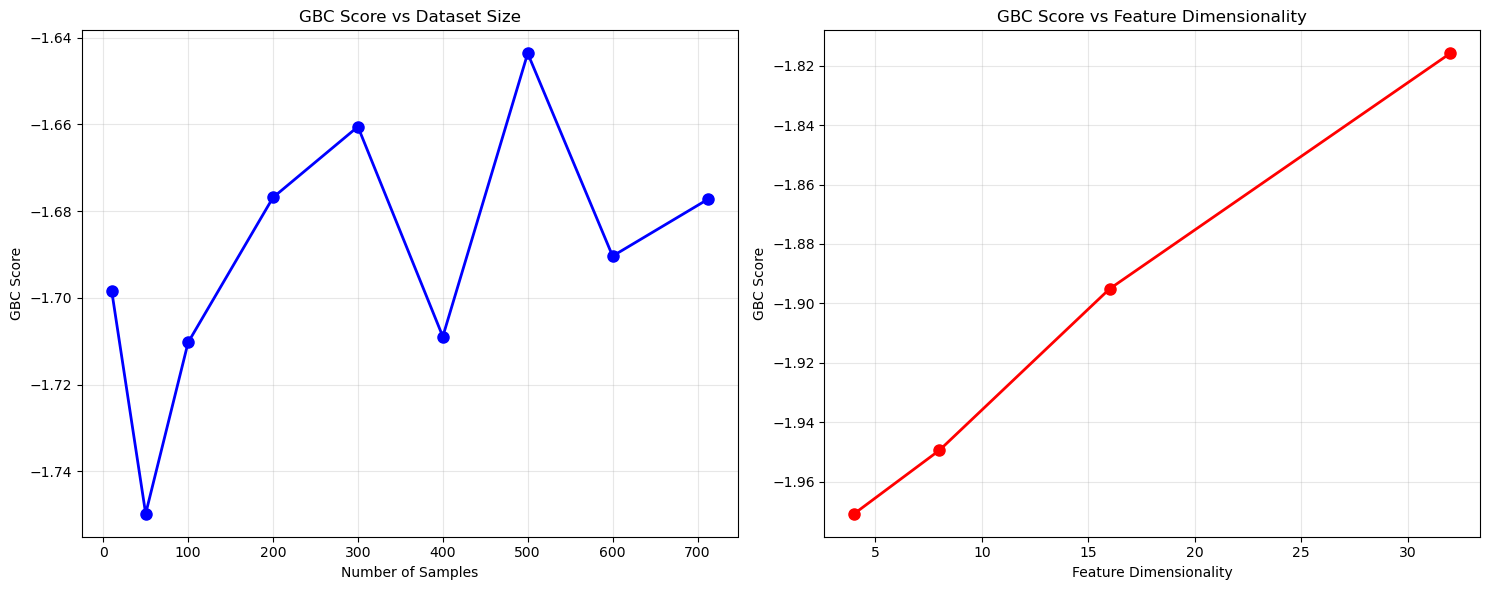

GBC range for dataset size: 0.106186
GBC range for feature dimensionality: 0.154990
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.984612
Sample size:     50, GBC: -1.977432
Sample size:    100, GBC: -1.984111
Sample size:    200, GBC: -1.986563
Sample size:    300, GBC: -1.982201
Sample size:    400, GBC: -1.983327
Sample size:    500, GBC: -1.983327
Sample size:    600, GBC: -1.980888
Sample size:    712, GBC: -1.980450
Non-zero patches found: 712
Feature dim:   4, GBC: -1.982276, Explained var: 0.981
Feature dim:   8, GBC: -1.960638, Explained var: 0.997
Feature dim:  16, GBC: -1.944113, Explained var: 1.000
Feature dim:  32, GBC: -1.933218, Explained var: 1.000
Model: Hm_model4, Target: EPFL


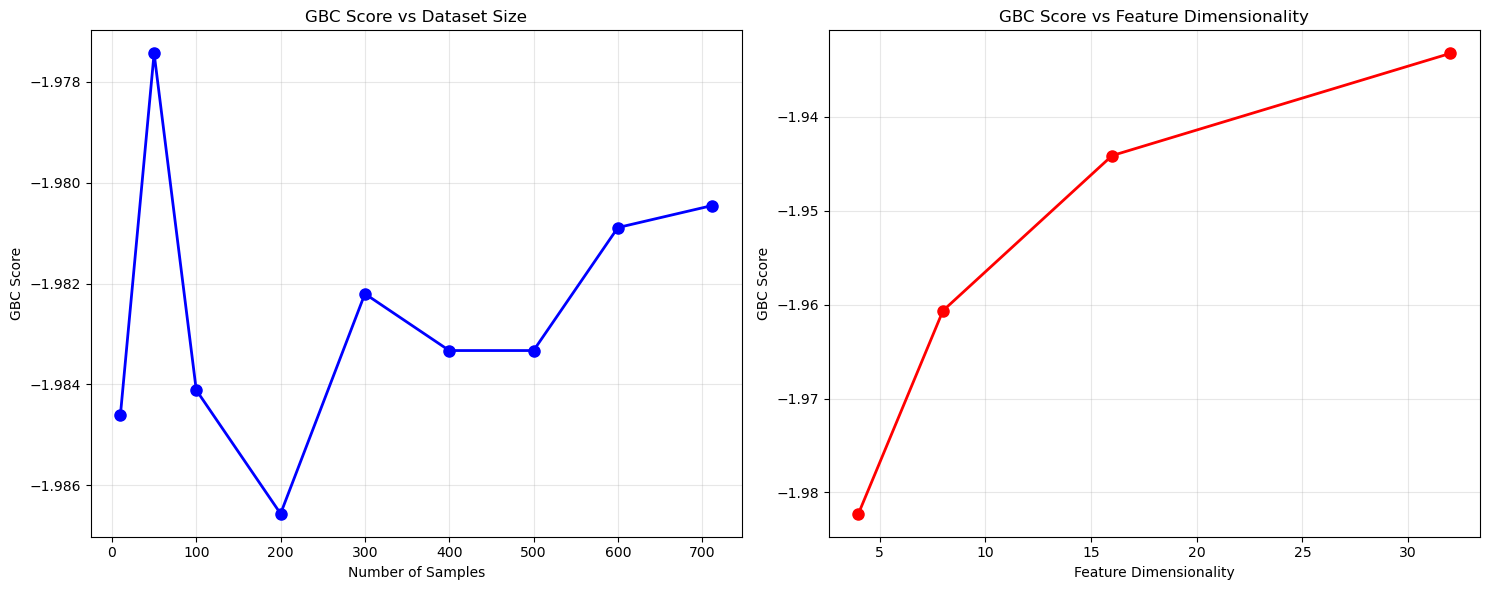

GBC range for dataset size: 0.009131
GBC range for feature dimensionality: 0.049058
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.947778
Sample size:     50, GBC: -1.752967
Sample size:    100, GBC: -1.897845
Sample size:    200, GBC: -1.874322
Sample size:    300, GBC: -1.915352
Sample size:    400, GBC: -1.907044
Sample size:    500, GBC: -1.930925
Sample size:    600, GBC: -1.917004
Sample size:    712, GBC: -1.920997
Non-zero patches found: 712
Feature dim:   4, GBC: -1.994799, Explained var: 0.989
Feature dim:   8, GBC: -1.994534, Explained var: 0.998
Feature dim:  16, GBC: -1.993297, Explained var: 0.999
Feature dim:  32, GBC: -1.990593, Explained var: 1.000
Model: Rm_model4, Target: EPFL


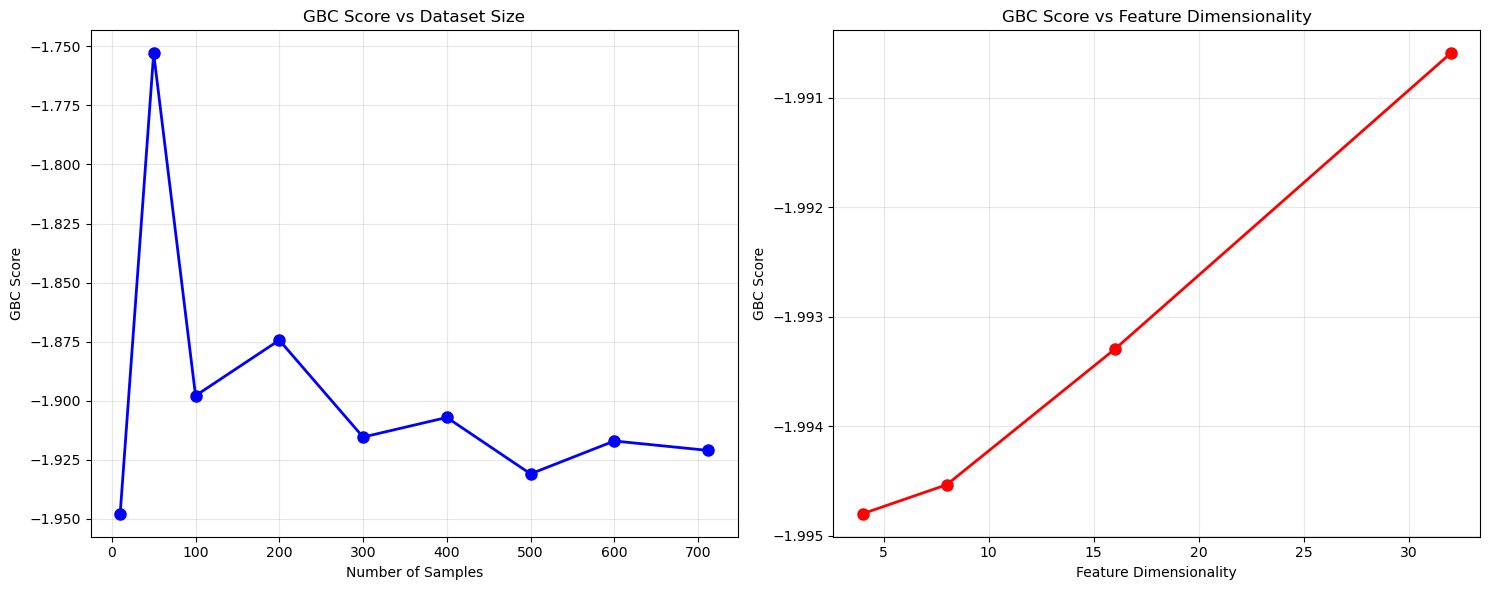

GBC range for dataset size: 0.194811
GBC range for feature dimensionality: 0.004206
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.988769
Sample size:     50, GBC: -1.824865
Sample size:    100, GBC: -1.923429
Sample size:    200, GBC: -1.866745
Sample size:    300, GBC: -1.936706
Sample size:    400, GBC: -1.923380
Sample size:    500, GBC: -1.943993
Sample size:    600, GBC: -1.925556
Sample size:    712, GBC: -1.935901
Non-zero patches found: 712
Feature dim:   4, GBC: -1.996819, Explained var: 0.986
Feature dim:   8, GBC: -1.996374, Explained var: 0.998
Feature dim:  16, GBC: -1.995410, Explained var: 1.000
Feature dim:  32, GBC: -1.991641, Explained var: 1.000
Model: V_model2, Target: EPFL


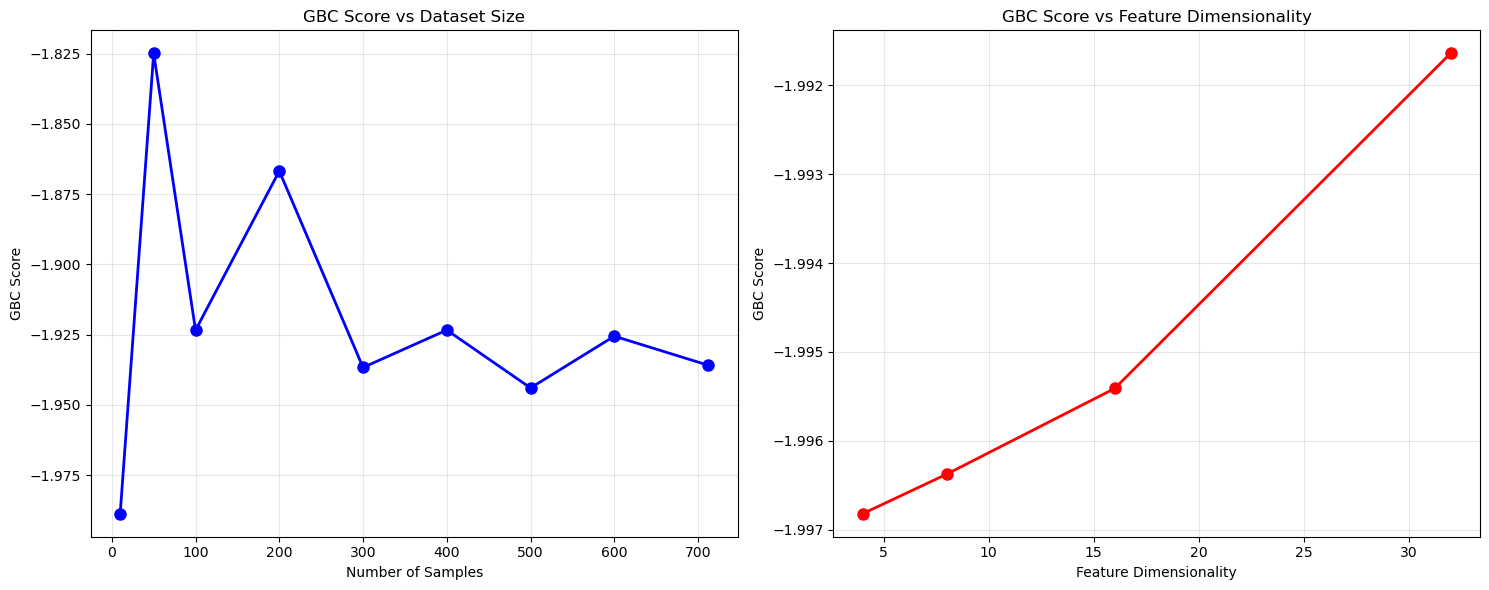

GBC range for dataset size: 0.163904
GBC range for feature dimensionality: 0.005177
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.991145
Sample size:     50, GBC: -1.912362
Sample size:    100, GBC: -1.894658
Sample size:    200, GBC: -1.880367
Sample size:    300, GBC: -1.844106
Sample size:    400, GBC: -1.868937
Sample size:    500, GBC: -1.852014
Sample size:    600, GBC: -1.861417
Sample size:    712, GBC: -1.851664
Non-zero patches found: 712
Feature dim:   4, GBC: -1.991578, Explained var: 0.981
Feature dim:   8, GBC: -1.991350, Explained var: 0.996
Feature dim:  16, GBC: -1.987167, Explained var: 1.000
Feature dim:  32, GBC: -1.986582, Explained var: 1.000
Model: E_model_NA2, Target: EPFL


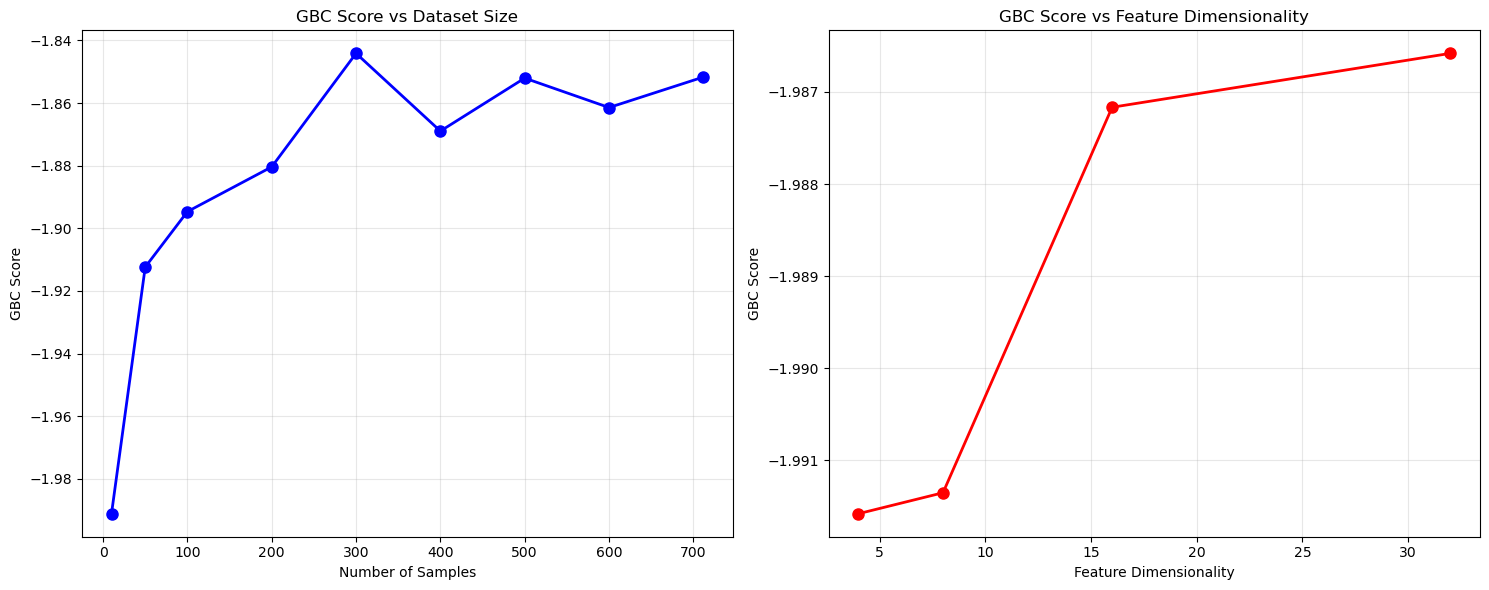

GBC range for dataset size: 0.147039
GBC range for feature dimensionality: 0.004996
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.820201
Sample size:     50, GBC: -1.962452
Sample size:    100, GBC: -1.972299
Sample size:    200, GBC: -1.957761
Sample size:    300, GBC: -1.975308
Sample size:    400, GBC: -1.969169
Sample size:    500, GBC: -1.970175
Sample size:    600, GBC: -1.971731
Sample size:    712, GBC: -1.971429
Non-zero patches found: 712
Feature dim:   4, GBC: -1.997225, Explained var: 0.974
Feature dim:   8, GBC: -1.986344, Explained var: 0.995
Feature dim:  16, GBC: -1.965565, Explained var: 0.999
Feature dim:  32, GBC: -1.956134, Explained var: 1.000
Model: Hm_model_NA2, Target: EPFL


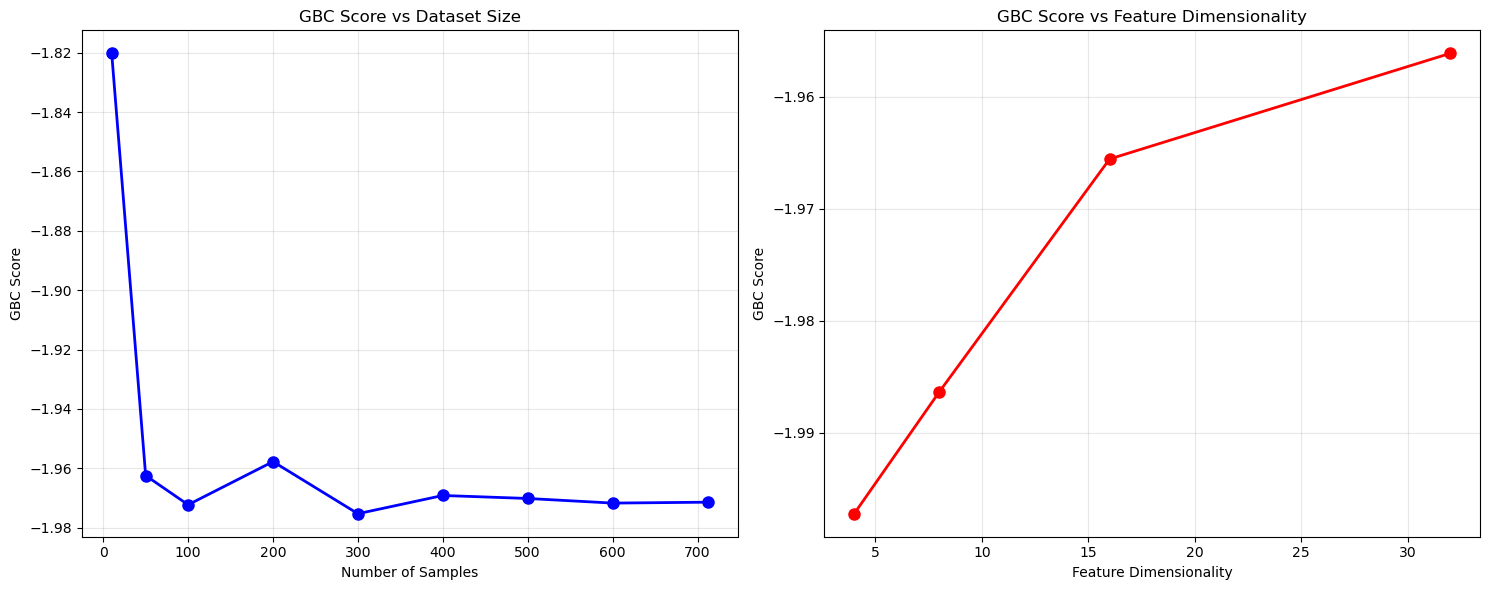

GBC range for dataset size: 0.155106
GBC range for feature dimensionality: 0.041092
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.942043
Sample size:     50, GBC: -1.963447
Sample size:    100, GBC: -1.976294
Sample size:    200, GBC: -1.953895
Sample size:    300, GBC: -1.960242
Sample size:    400, GBC: -1.950840
Sample size:    500, GBC: -1.964703
Sample size:    600, GBC: -1.952707
Sample size:    712, GBC: -1.956164
Non-zero patches found: 712
Feature dim:   4, GBC: -1.995921, Explained var: 0.982
Feature dim:   8, GBC: -1.993119, Explained var: 0.994
Feature dim:  16, GBC: -1.982183, Explained var: 0.998
Feature dim:  32, GBC: -1.978876, Explained var: 1.000
Model: Rm_model_NA2, Target: EPFL


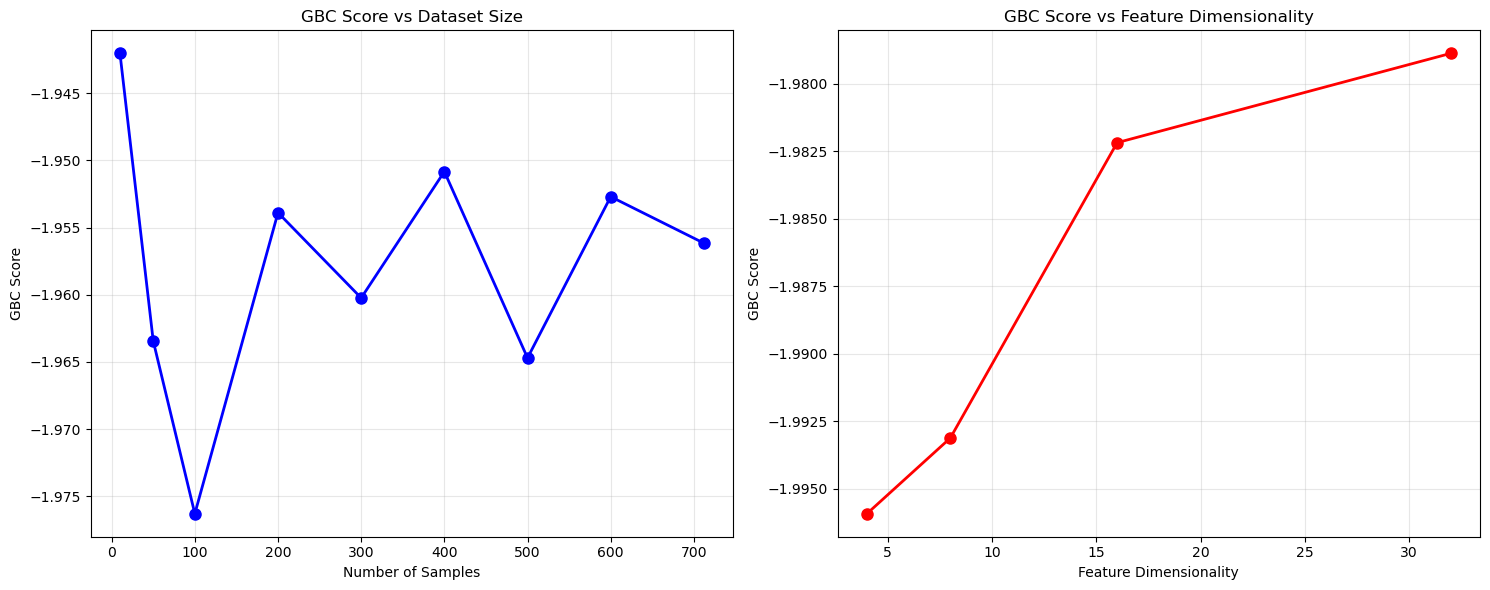

GBC range for dataset size: 0.034251
GBC range for feature dimensionality: 0.017045
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.996642
Sample size:     50, GBC: -1.996285
Sample size:    100, GBC: -1.977744
Sample size:    200, GBC: -1.985759
Sample size:    300, GBC: -1.988850
Sample size:    400, GBC: -1.994416
Sample size:    500, GBC: -1.989254
Sample size:    600, GBC: -1.995593
Sample size:    712, GBC: -1.993502
Non-zero patches found: 712
Feature dim:   4, GBC: -1.972823, Explained var: 0.994
Feature dim:   8, GBC: -1.953350, Explained var: 0.999
Feature dim:  16, GBC: -1.917827, Explained var: 1.000
Feature dim:  32, GBC: -1.869833, Explained var: 1.000
Model: V_model_NA2, Target: EPFL


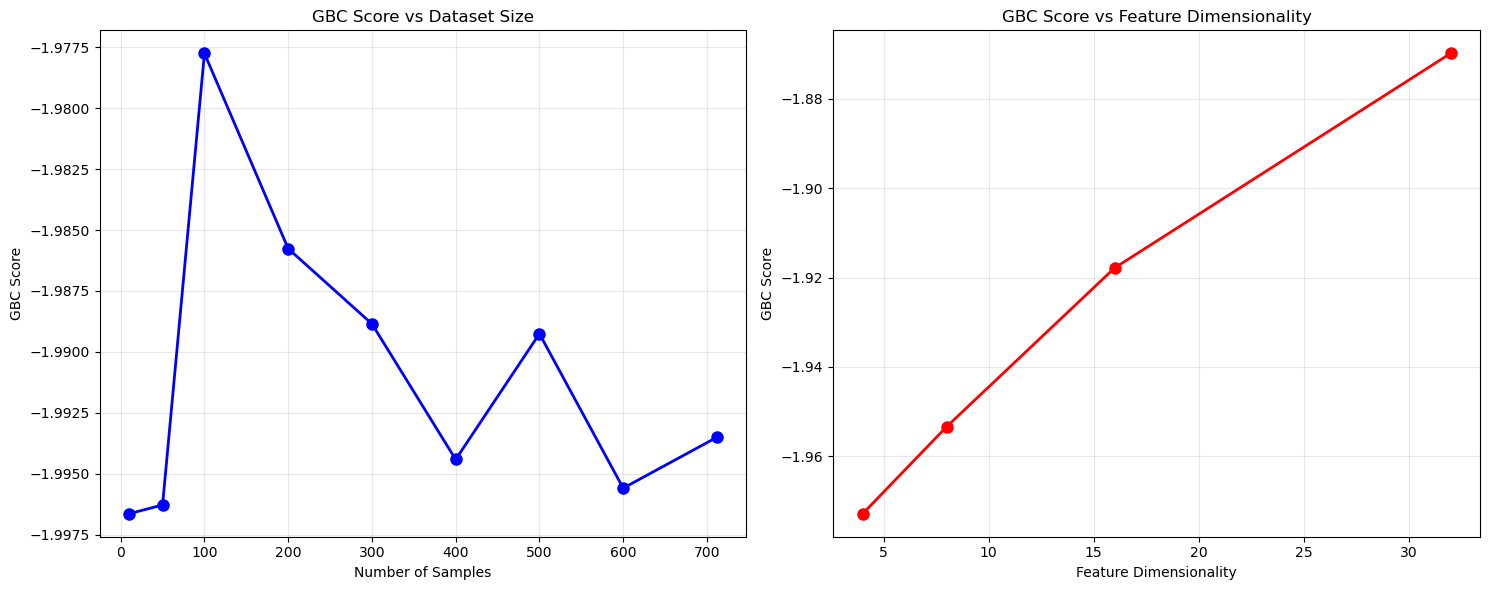

GBC range for dataset size: 0.018898
GBC range for feature dimensionality: 0.102990
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.957196
Sample size:     50, GBC: -1.985665
Sample size:    100, GBC: -1.989623
Sample size:    200, GBC: -1.984632
Sample size:    300, GBC: -1.985434
Sample size:    400, GBC: -1.992357
Sample size:    500, GBC: -1.988902
Sample size:    600, GBC: -1.989535
Sample size:    712, GBC: -1.990542
Non-zero patches found: 712
Feature dim:   4, GBC: -1.987866, Explained var: 0.899
Feature dim:   8, GBC: -1.952197, Explained var: 0.982
Feature dim:  16, GBC: -1.914075, Explained var: 1.000
Model: E_model_Unetr2, Target: EPFL


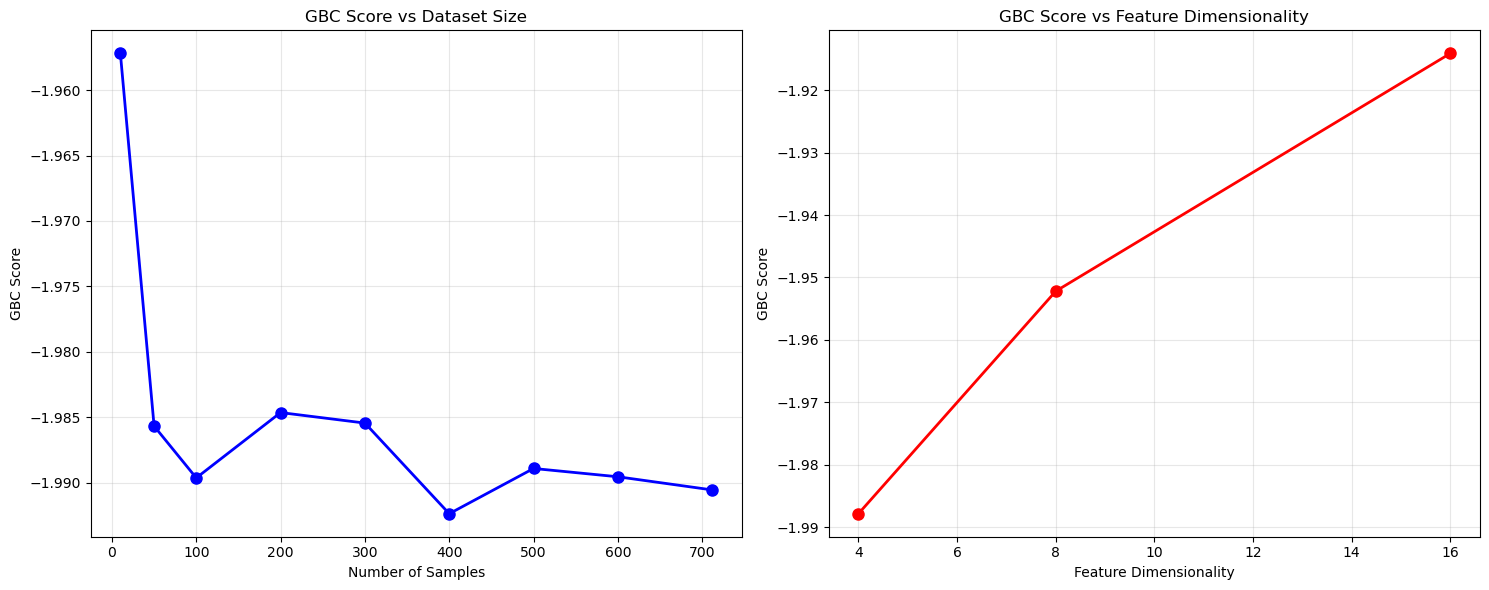

GBC range for dataset size: 0.035160
GBC range for feature dimensionality: 0.073791
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.900717
Sample size:     50, GBC: -1.858913
Sample size:    100, GBC: -1.891445
Sample size:    200, GBC: -1.883610
Sample size:    300, GBC: -1.925749
Sample size:    400, GBC: -1.924696
Sample size:    500, GBC: -1.921916
Sample size:    600, GBC: -1.925901
Sample size:    712, GBC: -1.928923
Non-zero patches found: 712
Feature dim:   4, GBC: -1.988557, Explained var: 0.950
Feature dim:   8, GBC: -1.957555, Explained var: 0.996
Feature dim:  16, GBC: -1.914267, Explained var: 1.000
Model: Hm_model_Unetr2, Target: EPFL


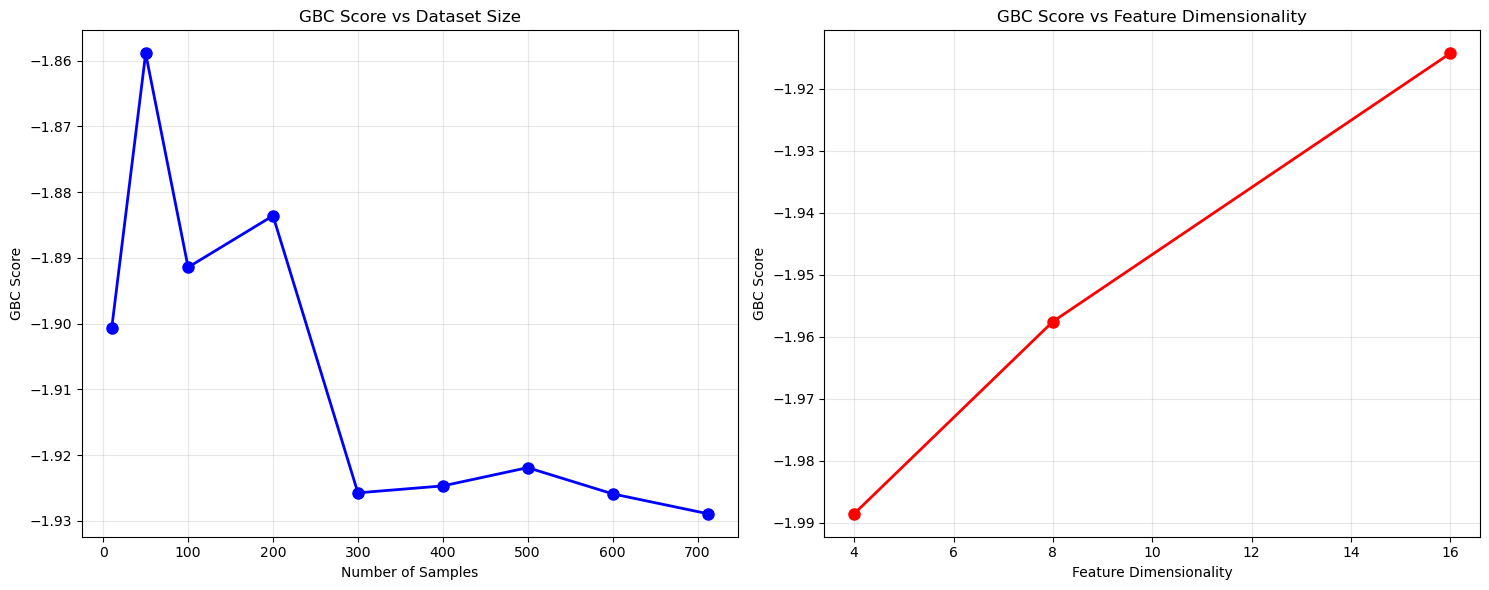

GBC range for dataset size: 0.070010
GBC range for feature dimensionality: 0.074290
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.845068
Sample size:     50, GBC: -1.879492
Sample size:    100, GBC: -1.906373
Sample size:    200, GBC: -1.885813
Sample size:    300, GBC: -1.898511
Sample size:    400, GBC: -1.900856
Sample size:    500, GBC: -1.890743
Sample size:    600, GBC: -1.901186
Sample size:    712, GBC: -1.898479
Non-zero patches found: 712
Feature dim:   4, GBC: -1.967794, Explained var: 0.954
Feature dim:   8, GBC: -1.931999, Explained var: 0.988
Feature dim:  16, GBC: -1.899496, Explained var: 1.000
Model: Rm_model_Unetr2, Target: EPFL


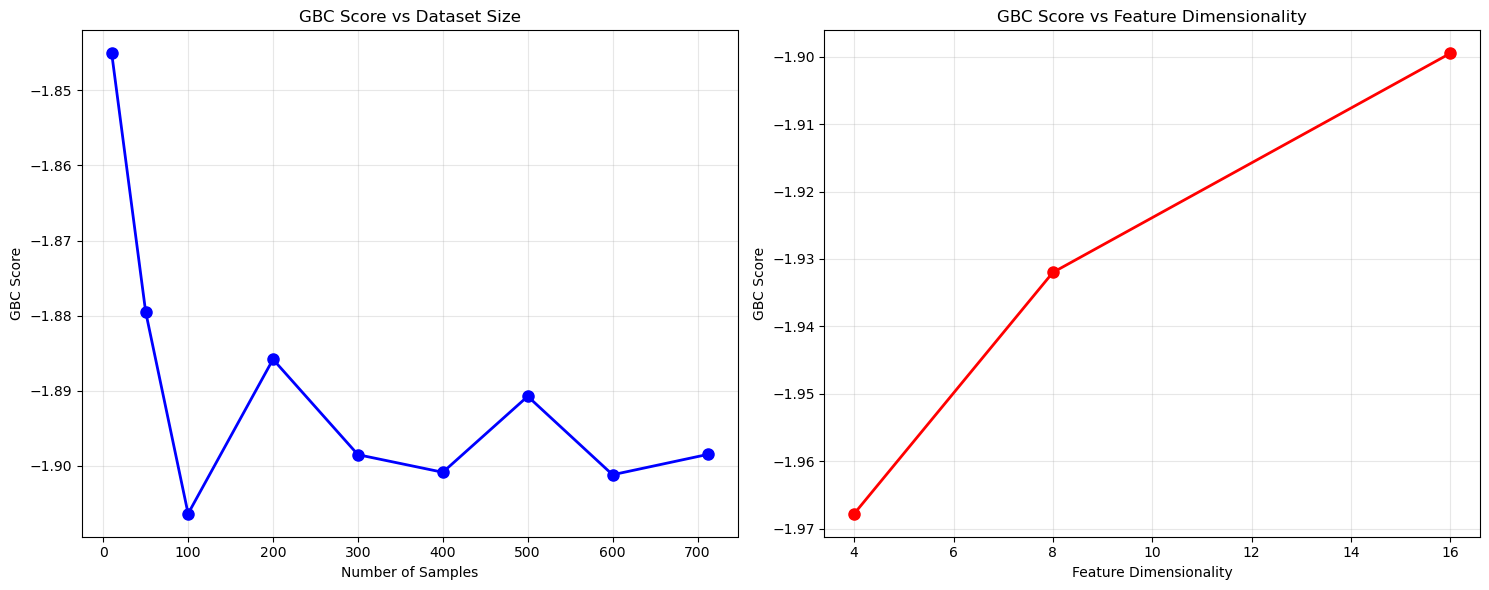

GBC range for dataset size: 0.061305
GBC range for feature dimensionality: 0.068298
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.959670
Sample size:     50, GBC: -1.968594
Sample size:    100, GBC: -1.976357
Sample size:    200, GBC: -1.964202
Sample size:    300, GBC: -1.967509
Sample size:    400, GBC: -1.972242
Sample size:    500, GBC: -1.969940
Sample size:    600, GBC: -1.972191
Sample size:    712, GBC: -1.971518
Non-zero patches found: 712
Feature dim:   4, GBC: -1.981543, Explained var: 0.902
Feature dim:   8, GBC: -1.970685, Explained var: 0.940
Feature dim:  16, GBC: -1.947724, Explained var: 0.970
Feature dim:  32, GBC: -1.940318, Explained var: 0.991
Feature dim:  64, GBC: -1.934101, Explained var: 1.000
Model: E_model_Res1, Target: EPFL


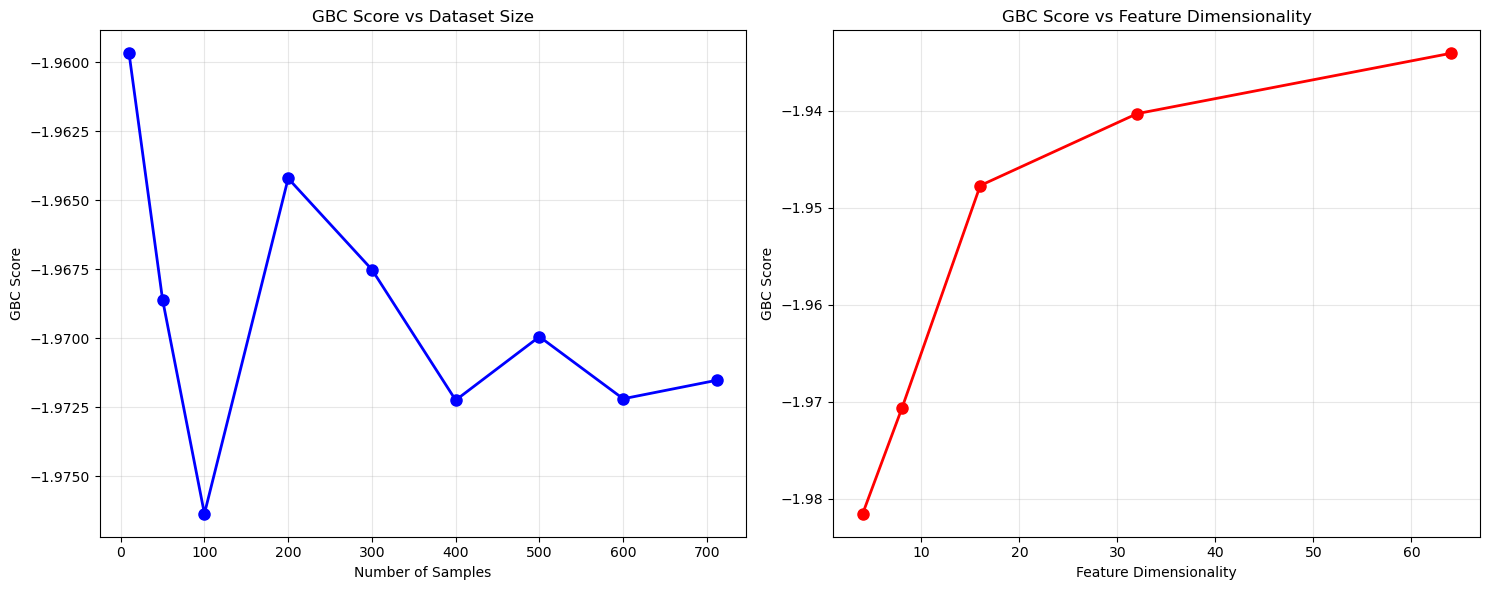

GBC range for dataset size: 0.016686
GBC range for feature dimensionality: 0.047442
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.852204
Sample size:     50, GBC: -1.529568
Sample size:    100, GBC: -1.828118
Sample size:    200, GBC: -1.892132
Sample size:    300, GBC: -1.893385
Sample size:    400, GBC: -1.846931
Sample size:    500, GBC: -1.884026
Sample size:    600, GBC: -1.884876
Sample size:    712, GBC: -1.893806
Non-zero patches found: 712
Feature dim:   4, GBC: -1.976114, Explained var: 0.897
Feature dim:   8, GBC: -1.918510, Explained var: 0.960
Feature dim:  16, GBC: -1.885215, Explained var: 0.984
Feature dim:  32, GBC: -1.859003, Explained var: 0.995
Feature dim:  64, GBC: -1.843834, Explained var: 1.000
Model: Hm_model_Res1, Target: EPFL


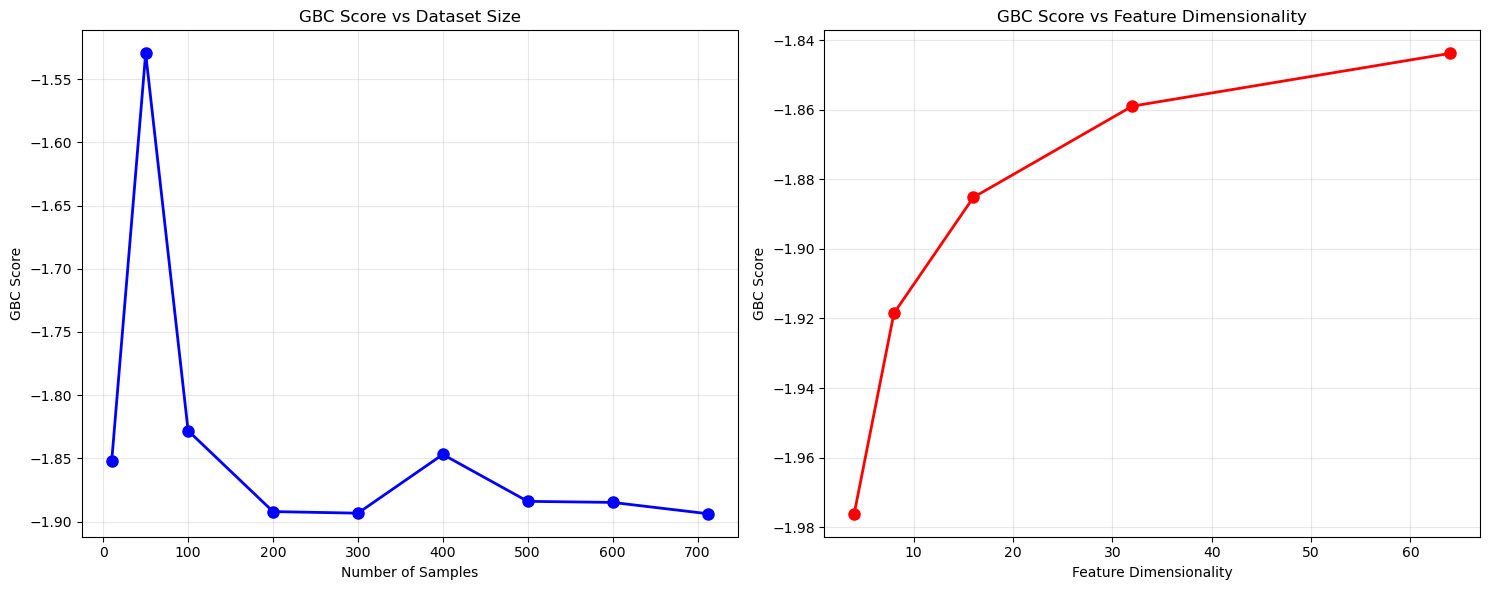

GBC range for dataset size: 0.364239
GBC range for feature dimensionality: 0.132280
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.909664
Sample size:     50, GBC: -1.952255
Sample size:    100, GBC: -1.969858
Sample size:    200, GBC: -1.959294
Sample size:    300, GBC: -1.979853
Sample size:    400, GBC: -1.973503
Sample size:    500, GBC: -1.976021
Sample size:    600, GBC: -1.977002
Sample size:    712, GBC: -1.979078
Non-zero patches found: 712
Feature dim:   4, GBC: -1.995985, Explained var: 0.941
Feature dim:   8, GBC: -1.992892, Explained var: 0.968
Feature dim:  16, GBC: -1.989033, Explained var: 0.986
Feature dim:  32, GBC: -1.983659, Explained var: 0.995
Feature dim:  64, GBC: -1.971451, Explained var: 1.000
Model: Rm_model_Res1, Target: EPFL


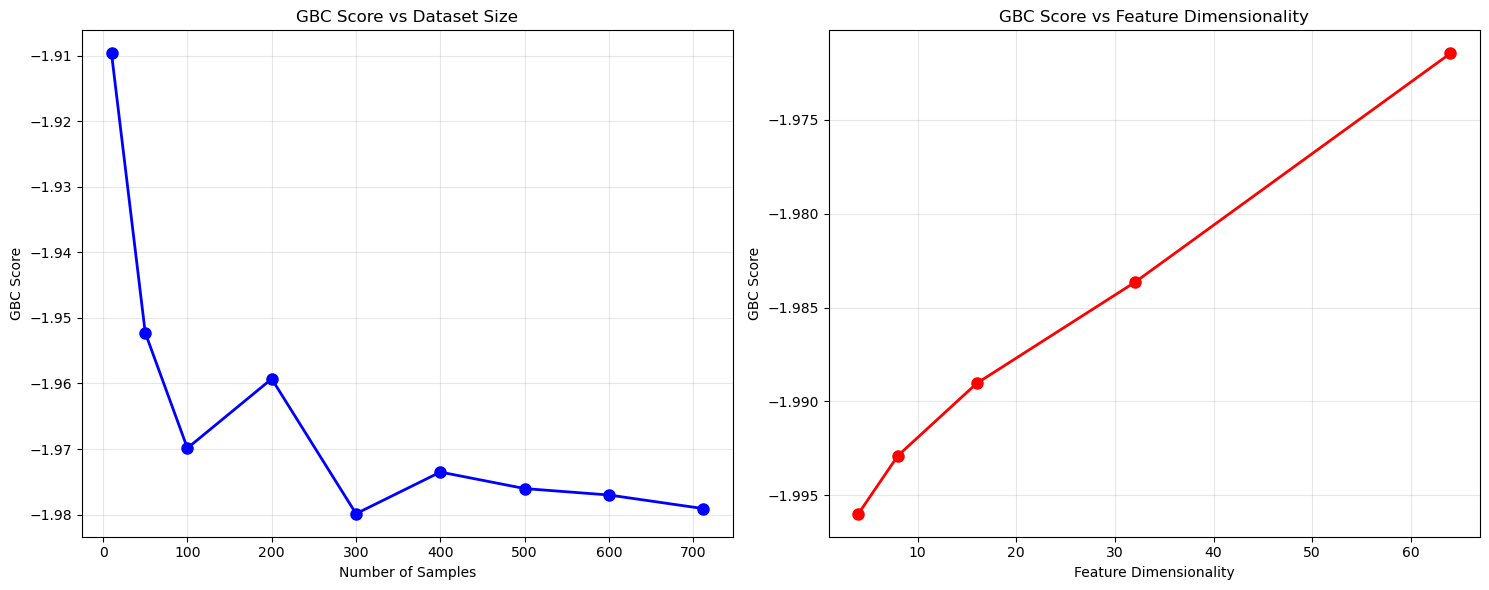

GBC range for dataset size: 0.070189
GBC range for feature dimensionality: 0.024534
Non-zero patches found: 712

--- Sample size dependency (full real data) ---
Sample size:     10, GBC: -1.711719
Sample size:     50, GBC: -1.827219
Sample size:    100, GBC: -1.818910
Sample size:    200, GBC: -1.811397
Sample size:    300, GBC: -1.842485
Sample size:    400, GBC: -1.821556
Sample size:    500, GBC: -1.807355
Sample size:    600, GBC: -1.825511
Sample size:    712, GBC: -1.821476
Non-zero patches found: 712
Feature dim:   4, GBC: -1.988886, Explained var: 0.906
Feature dim:   8, GBC: -1.971674, Explained var: 0.948
Feature dim:  16, GBC: -1.947454, Explained var: 0.974
Feature dim:  32, GBC: -1.923577, Explained var: 0.992
Feature dim:  64, GBC: -1.904848, Explained var: 1.000
Model: V_model_Res1, Target: EPFL


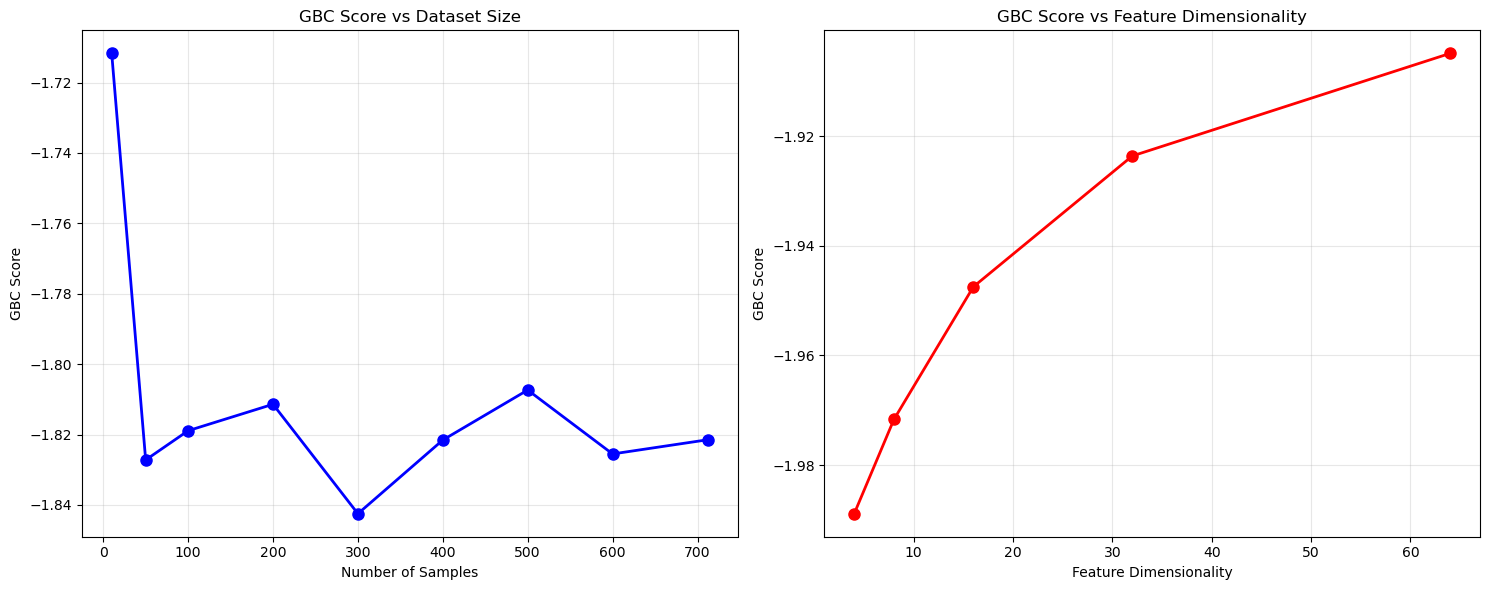

GBC range for dataset size: 0.130766
GBC range for feature dimensionality: 0.084037


In [61]:
targets = ["EPFL"]
source_models = Unet_models + Unet_models_NA + Unetr_models + ResUnet_models
feature_base_path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria"
save_keys = {
    "NA": "decoders.2",
    "Unetr": "decoder2",
    "Res": "decoders.3",
}
gbc_per_target = {}
feature_ids = list(save_keys.keys())
for target in targets:
    gbc_per_model = {}
    for model in source_models:
        if ("V" in model) and (target == "VNC"):
            continue
        else:
            model_identifier = model.split('_')[-1][:-1]
            if model_identifier in feature_ids:
                key = save_keys[model_identifier]
            else:
                key = "decoders.2"

            feature_path = get_precomputed_feature_path(model, target, feature_base_path)
            features = load_npz(feature_path, f"{key}_features")
            labels = load_npz(feature_path, f"{key}_labels")

            if model_identifier == "Res":
                feature_dims = [4,8,16,32,64]
            elif model_identifier == "Unetr":
                feature_dims = [4,8,16]
            else:
                feature_dims = [4,8,16,32]

            num_patches, gbc_score_dataset_size = test_gbc_num_sample_dependency(features, labels)
            gbc_score_nDfeatures = test_gbc_feature_size_dependency(features, labels, feature_dims)
            print("="*30)
            print(f"Model: {model}, Target: {target}")
            plot_gbc_dependency_analysis(
                num_patches, 
                feature_dims, 
                gbc_score_dataset_size, 
                gbc_score_nDfeatures
            )

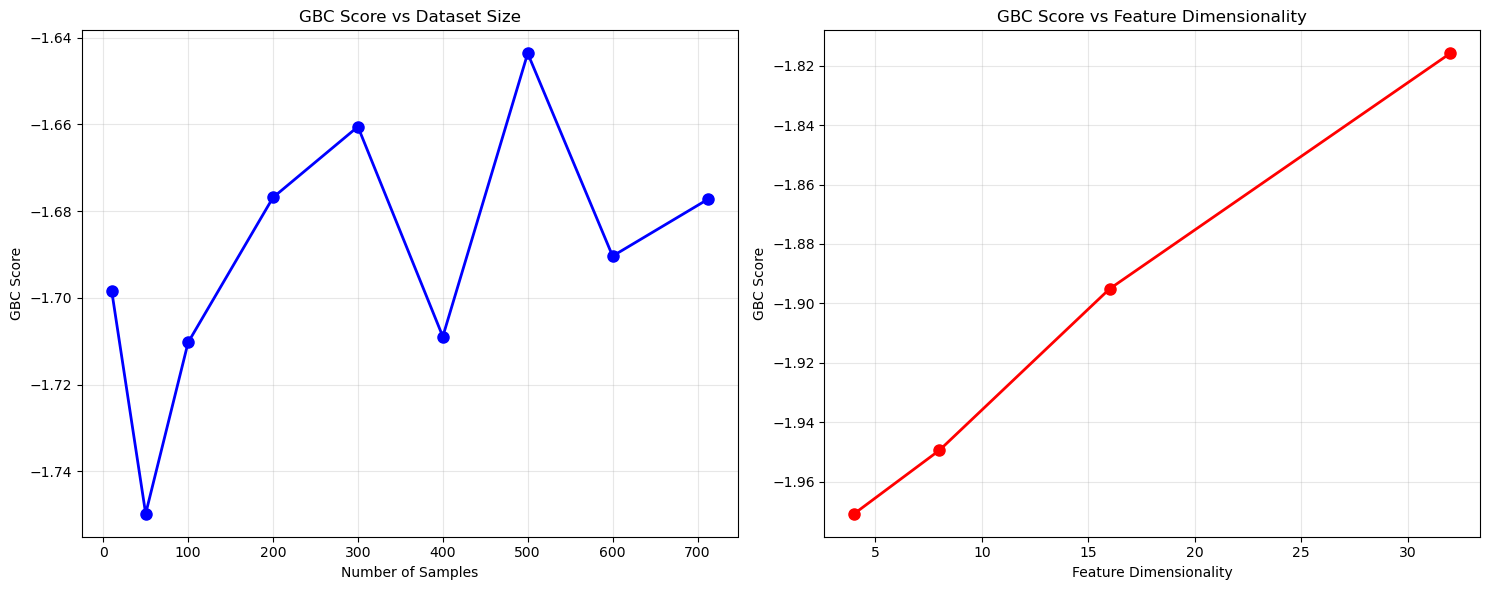

GBC range for dataset size: 0.106186
GBC range for feature dimensionality: 0.154990


In [ ]:


# Call the function with existing variables
plot_gbc_dependency_analysis(num_patches, [4, 8, 16, 32], gbc_score_dataset_size, gbc_score_nDfeatures)

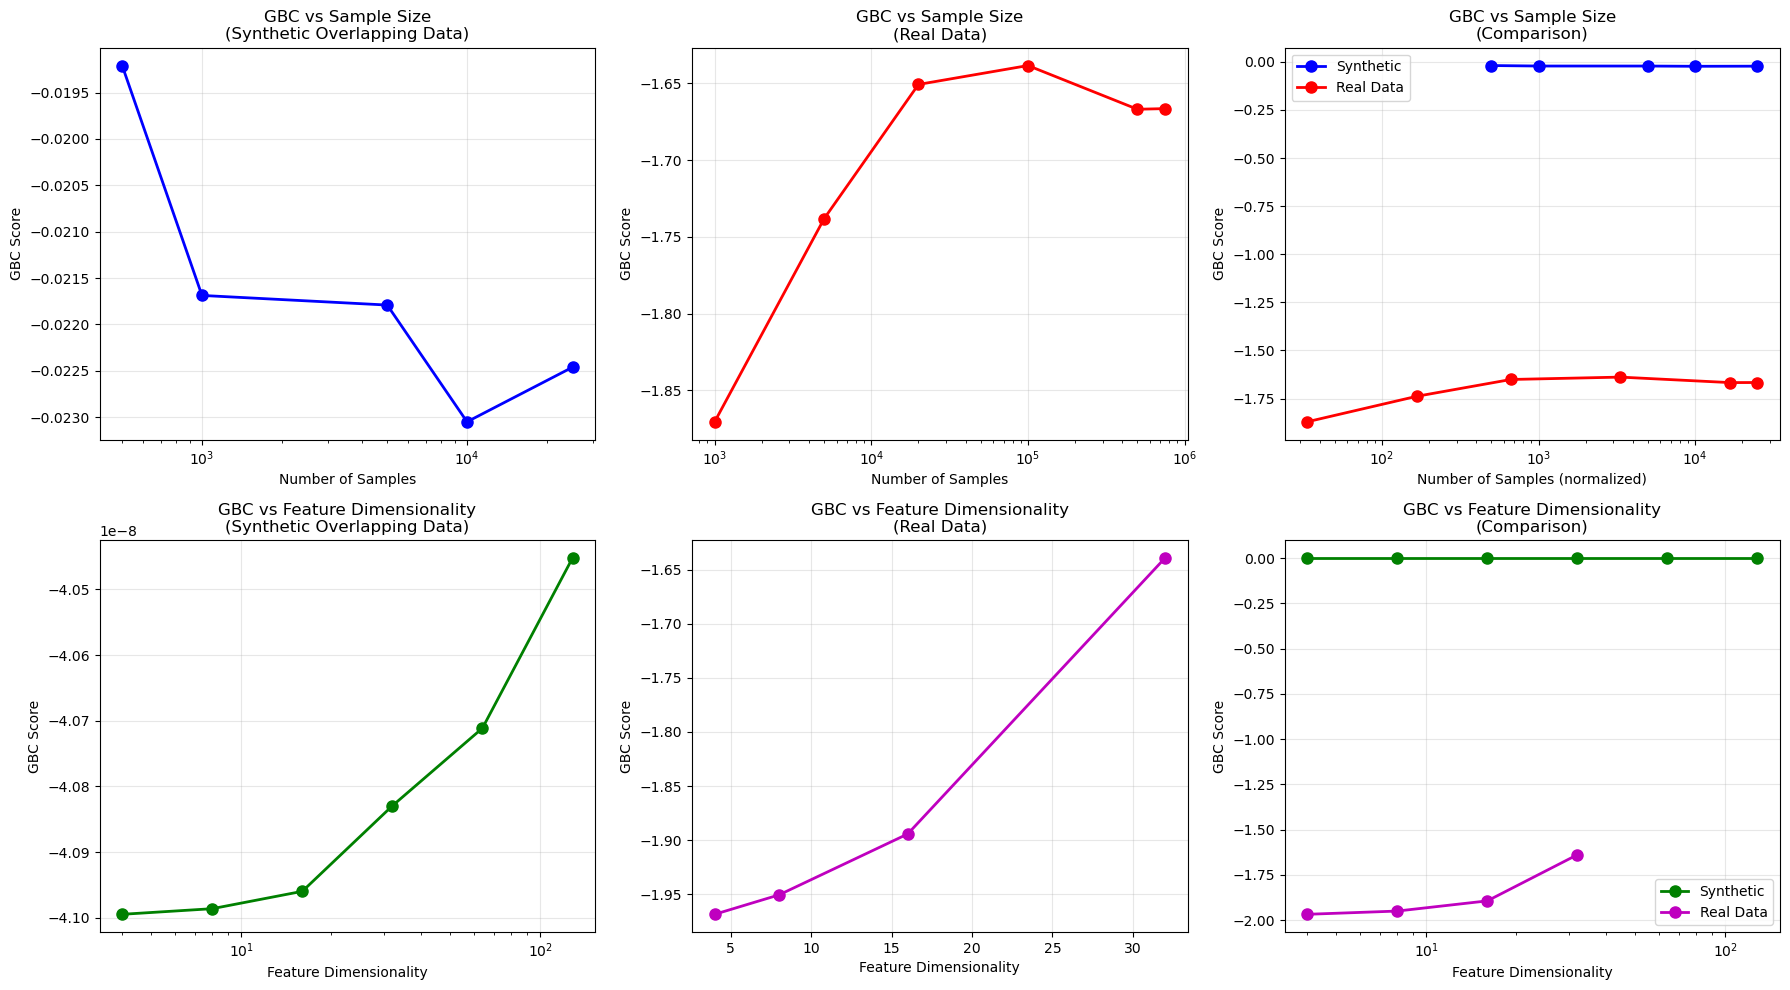

QUANTITATIVE ANALYSIS OF GBC DEPENDENCIES

1. SAMPLE SIZE DEPENDENCY:
----------------------------------------
Synthetic data:
  GBC range: 0.003844
  GBC variance: 0.00000172
  Coefficient of variation: 0.0606
Real data:
  GBC range: 0.232306
  GBC variance: 0.00647991
  Coefficient of variation: 0.0472

2. FEATURE DIMENSIONALITY DEPENDENCY:
----------------------------------------
Synthetic data:
  GBC range: 0.000000
  GBC variance: 0.00000000
  Coefficient of variation: 0.0047
Real data:
  GBC range: 0.329074
  GBC variance: 0.01744085
  Coefficient of variation: 0.0709

3. RELATIVE IMPACT COMPARISON:
----------------------------------------
Sample size vs dimensionality impact (synthetic data):
  Sample size coefficient of variation: 0.0606
  Dimensionality coefficient of variation: 0.0047
  Dimensionality impact is 0.1x stronger

Sample size vs dimensionality impact (real data):
  Sample size coefficient of variation: 0.0472
  Dimensionality coefficient of variation: 0.0709
  Dim

In [48]:
# Create comprehensive visualization and analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Sample size dependency
# Synthetic overlapping data
axes[0, 0].plot(sample_sizes_overlap, gbc_overlap_size, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Samples')
axes[0, 0].set_ylabel('GBC Score')
axes[0, 0].set_title('GBC vs Sample Size\n(Synthetic Overlapping Data)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')

# Real data
axes[0, 1].plot(real_sample_sizes, gbc_full_size, 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Samples')
axes[0, 1].set_ylabel('GBC Score')
axes[0, 1].set_title('GBC vs Sample Size\n(Real Data)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale('log')

# Combined comparison
axes[0, 2].plot(sample_sizes_overlap, gbc_overlap_size, 'bo-', label='Synthetic', linewidth=2, markersize=8)
# Normalize real data sample sizes for comparison
norm_real_sizes = [s/max(real_sample_sizes) * max(sample_sizes_overlap) for s in real_sample_sizes]
axes[0, 2].plot(norm_real_sizes, gbc_full_size, 'ro-', label='Real Data', linewidth=2, markersize=8)
axes[0, 2].set_xlabel('Number of Samples (normalized)')
axes[0, 2].set_ylabel('GBC Score')
axes[0, 2].set_title('GBC vs Sample Size\n(Comparison)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_xscale('log')

# Row 2: Dimensionality dependency
# Synthetic overlapping data
axes[1, 0].plot(dimensions_overlap, gbc_overlap_dim, 'go-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Feature Dimensionality')
axes[1, 0].set_ylabel('GBC Score')
axes[1, 0].set_title('GBC vs Feature Dimensionality\n(Synthetic Overlapping Data)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log')

# Real data
axes[1, 1].plot(real_dims_full, gbc_full_dim, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Feature Dimensionality')
axes[1, 1].set_ylabel('GBC Score')
axes[1, 1].set_title('GBC vs Feature Dimensionality\n(Real Data)')
axes[1, 1].grid(True, alpha=0.3)

# Combined comparison
axes[1, 2].plot(dimensions_overlap, gbc_overlap_dim, 'go-', label='Synthetic', linewidth=2, markersize=8)
axes[1, 2].plot(real_dims_full, gbc_full_dim, 'mo-', label='Real Data', linewidth=2, markersize=8)
axes[1, 2].set_xlabel('Feature Dimensionality')
axes[1, 2].set_ylabel('GBC Score')
axes[1, 2].set_title('GBC vs Feature Dimensionality\n(Comparison)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xscale('log')

plt.tight_layout()
plt.show()

# Print quantitative analysis
print("=" * 80)
print("QUANTITATIVE ANALYSIS OF GBC DEPENDENCIES")
print("=" * 80)

print("\n1. SAMPLE SIZE DEPENDENCY:")
print("-" * 40)

# Synthetic data analysis
gbc_range_synthetic = max(gbc_overlap_size) - min(gbc_overlap_size)
gbc_var_synthetic = np.var(gbc_overlap_size)
print(f"Synthetic data:")
print(f"  GBC range: {gbc_range_synthetic:.6f}")
print(f"  GBC variance: {gbc_var_synthetic:.8f}")
print(f"  Coefficient of variation: {np.std(gbc_overlap_size)/abs(np.mean(gbc_overlap_size)):.4f}")

# Real data analysis
gbc_range_real = max(gbc_full_size) - min(gbc_full_size)
gbc_var_real = np.var(gbc_full_size)
print(f"Real data:")
print(f"  GBC range: {gbc_range_real:.6f}")
print(f"  GBC variance: {gbc_var_real:.8f}")
print(f"  Coefficient of variation: {np.std(gbc_full_size)/abs(np.mean(gbc_full_size)):.4f}")

print("\n2. FEATURE DIMENSIONALITY DEPENDENCY:")
print("-" * 40)

# Synthetic data dimensionality analysis
gbc_range_dim_synthetic = max(gbc_overlap_dim) - min(gbc_overlap_dim)
gbc_var_dim_synthetic = np.var(gbc_overlap_dim)
print(f"Synthetic data:")
print(f"  GBC range: {gbc_range_dim_synthetic:.6f}")
print(f"  GBC variance: {gbc_var_dim_synthetic:.8f}")
print(f"  Coefficient of variation: {np.std(gbc_overlap_dim)/abs(np.mean(gbc_overlap_dim)):.4f}")

# Real data dimensionality analysis
gbc_range_dim_real = max(gbc_full_dim) - min(gbc_full_dim)
gbc_var_dim_real = np.var(gbc_full_dim)
print(f"Real data:")
print(f"  GBC range: {gbc_range_dim_real:.6f}")
print(f"  GBC variance: {gbc_var_dim_real:.8f}")
print(f"  Coefficient of variation: {np.std(gbc_full_dim)/abs(np.mean(gbc_full_dim)):.4f}")

print("\n3. RELATIVE IMPACT COMPARISON:")
print("-" * 40)
print(f"Sample size vs dimensionality impact (synthetic data):")
print(f"  Sample size coefficient of variation: {np.std(gbc_overlap_size)/abs(np.mean(gbc_overlap_size)):.4f}")
print(f"  Dimensionality coefficient of variation: {np.std(gbc_overlap_dim)/abs(np.mean(gbc_overlap_dim)):.4f}")
print(f"  Dimensionality impact is {(np.std(gbc_overlap_dim)/abs(np.mean(gbc_overlap_dim)))/(np.std(gbc_overlap_size)/abs(np.mean(gbc_overlap_size))):.1f}x stronger")

print(f"\nSample size vs dimensionality impact (real data):")
print(f"  Sample size coefficient of variation: {np.std(gbc_full_size)/abs(np.mean(gbc_full_size)):.4f}")
print(f"  Dimensionality coefficient of variation: {np.std(gbc_full_dim)/abs(np.mean(gbc_full_dim)):.4f}")
print(f"  Dimensionality impact is {(np.std(gbc_full_dim)/abs(np.mean(gbc_full_dim)))/(np.std(gbc_full_size)/abs(np.mean(gbc_full_size))):.1f}x stronger")

In [ ]:
def test_gbc_with_overlapping_classes():
    """Test GBC with more realistic overlapping class distributions."""
    print("\n=== Testing with overlapping classes ===")
    
    # Test sample size dependency with overlapping classes
    print("\n--- Sample size dependency (overlapping classes) ---")
    n_features = 32
    sample_sizes = [500, 1000, 5000, 10000, 25000]
    gbc_scores_overlap = []
    
    for n_samples in sample_sizes:
        # Create overlapping distributions
        np.random.seed(42)
        
        # Class 0: centered at origin
        class0_features = np.random.multivariate_normal(
            mean=np.zeros(n_features), 
            cov=np.eye(n_features) * 2.0,  # Higher variance for overlap
            size=n_samples//2
        )
        class0_labels = np.zeros(n_samples//2)
        
        # Class 1: centered at small offset to create overlap
        class1_features = np.random.multivariate_normal(
            mean=np.ones(n_features) * 1.5,  # Small separation for overlap
            cov=np.eye(n_features) * 2.0,
            size=n_samples//2
        )
        class1_labels = np.ones(n_samples//2)
        
        # Combine
        features = np.vstack([class0_features, class1_features])
        labels = np.hstack([class0_labels, class1_labels])
        
        gbc = bhattacharyya_coefficient(features, labels)
        gbc_scores_overlap.append(gbc)
        print(f"Sample size: {n_samples:5d}, GBC: {gbc:.6f}")
    
    # Test dimensionality dependency using PCA
    print("\n--- Feature dimensionality dependency (overlapping classes) ---")
    n_samples = 5000
    base_features = 128  # Generate high-dimensional data first
    dimensions = [4, 8, 16, 32, 64, 128]
    gbc_scores_dim_overlap = []
    
    # Generate high-dimensional base data
    np.random.seed(42)
    
    # Class 0: centered at origin
    class0_features = np.random.multivariate_normal(
        mean=np.zeros(base_features), 
        cov=np.eye(base_features) * 2.0,
        size=n_samples//2
    )
    class0_labels = np.zeros(n_samples//2)
    
    # Class 1: centered at small offset
    class1_features = np.random.multivariate_normal(
        mean=np.ones(base_features) * 1.5,
        cov=np.eye(base_features) * 2.0,
        size=n_samples//2
    )
    class1_labels = np.ones(n_samples//2)
    
    # Combine base features
    base_features_combined = np.vstack([class0_features, class1_features])
    labels = np.hstack([class0_labels, class1_labels])
    
    # Apply PCA for different dimensions
    from sklearn.decomposition import PCA
    
    for n_components in dimensions:
        if n_components > base_features:
            n_components = base_features
            
        # Apply PCA to reduce to n_components dimensions
        pca = PCA(n_components=n_components, random_state=42)
        features_pca = pca.fit_transform(base_features_combined)
        
        gbc = bhattacharyya_coefficient(features_pca, labels)
        gbc_scores_dim_overlap.append(gbc)
        explained_var = np.sum(pca.explained_variance_ratio_)
        print(f"Feature dim: {n_components:3d}, GBC: {gbc:.6f}, Explained var: {explained_var:.3f}")
    
    return sample_sizes, gbc_scores_overlap, dimensions, gbc_scores_dim_overlap

# Run overlapping class tests
sample_sizes_overlap, gbc_overlap_size, dimensions_overlap, gbc_overlap_dim = test_gbc_with_overlapping_classes()